# Effet de JDAC sur l'épaisseur corticale : pipeline rigide (ds004332)

**Objectif.** Déterminer si JDAC corrige le biais de mouvement sur l'épaisseur corticale, ou s'il applique un lissage uniforme.

**Cadre.** Une acquisition est définie par sujet, condition (still / nodding / shaking) et bras (brute / preproc / jdac). L'épaisseur corticale provient de FreeSurfer ; le mouvement est quantifié par le score Agitation (continu, en mm).

**Critère.** Une correction du mouvement réduit la pente de l'épaisseur en fonction de l'Agitation (effet du mouvement atténué). Un lissage déplace l'épaisseur globale (offset) sans modifier cette pente.

**Pipeline rigide.** N4, recalage rigide vers MNI, SynthStrip, puis FreeSurfer (et JDAC pour le bras correspondant). Le bras brut est commun aux deux pipelines (l'image brute n'a pas de version rigide).

**Acquisitions exclues (recon-all non abouti).**

| bras | n | runs manquants | cause |
|---|---|---|---|
| brute | 65/66 | sub-01_run-03 | surface piale (mouvement sévère) ; bras commun au pipeline natif |
| preproc | 64/66 | sub-10_run-01 ; sub-11_run-03 | normalisation d'intensité ; réparation de topologie |
| jdac | 64/66 | sub-10_run-03 ; sub-11_run-03 | réparation de topologie |

Notes :
- Les échecs en shaking (sub-11_run-03, sub-10_run-03) proviennent de défauts de topologie de surface trop nombreux à réparer, propres aux acquisitions très bougées.
- sub-10_run-01 (still) échoue dans le bras preproc mais aboutit dans le bras jdac. Sa matière blanche est anormalement brillante (rapport d'intensité matière blanche / grise = 1.53), ce qui fait échouer la normalisation d'intensité de FreeSurfer. Le bras jdac applique JDAC en amont ; son lissage comprime ce contraste (rapport 1.40) et rétablit la normalisation. Le même lissage explique donc à la fois la limite de JDAC pour la correction du mouvement et la réussite de cette acquisition dans le bras jdac.

## 1. Données et chargement

Les trois bras sont stockés dans deux dispositions. Le brut est en format empilé (une ligne par mesure : acquisition × région). Preproc et jdac sont en format en colonnes (une ligne par acquisition, une colonne par région) ; un dépliage (`melt`) les ramène au format empilé. Les trois bras sont ensuite réunis dans un tableau unique : une ligne par acquisition × hémisphère × région × bras, complété par le score Agitation, l'âge et le sexe.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from IPython.display import display
import warnings; warnings.filterwarnings("ignore")

def show(df, caption="", fmt="{:.3f}"):
    # Affiche un tableau lisible, zebre (fond alterne), avec titre.
    sty = (df.style.format(fmt, na_rep="")
             .set_caption(caption)
             .set_table_styles([
                 {"selector": "caption", "props": "caption-side:top;font-weight:bold;font-size:13px;text-align:left;padding:6px 0;"},
                 {"selector": "th", "props": "background-color:#d9e1f2;padding:6px 16px;font-size:13px;text-align:center;"},
                 {"selector": "td", "props": "padding:6px 16px;font-size:13px;text-align:right;"},
                 {"selector": "tbody tr:nth-child(odd)", "props": "background-color:#f5f5f5;"},
             ]))
    display(sty)

HOME = Path.home()
REPO  = HOME / "Documents/jdac-motion-correction"
DERIV = HOME / "Documents/derivatives/ds004332"
BRUTE_CSV    = REPO / "results/ds004332/phase1_RAW/ThickAvg_phase1_complete.csv"
AGIT_CSV     = REPO / "results/ds004332/agitation/ds004332_agitation_clinica.csv"
PARTICIPANTS = HOME / "Documents/raw_datasets/ds004332/participants.tsv"
COND = {"run-01": "still", "run-02": "nodding", "run-03": "shaking"}

def load_brute():
    # Brut : format empile (une ligne par mesure), colonne ThickAvg.
    # sub-01_run-03 retire (echec FreeSurfer, ThickAvg=0).
    d = pd.read_csv(BRUTE_CSV)
    d = d[d["ThickAvg"] > 0].copy()
    d["run"] = d["subject"].str.split("_").str[1]
    d["subject"] = d["subject"].str.split("_").str[0]
    d = d.rename(columns={"ThickAvg": "thickness"})
    d["arm"] = "brute"
    return d[["subject", "run", "hemi", "region", "thickness", "arm"]]

def load_wide(arm):
    # preproc / jdac : format en colonnes (une ligne par acquisition, une colonne par region).
    frames = []
    for hemi in ["lh", "rh"]:
        w = pd.read_csv(DERIV / f"thickness_{arm}_rigid_{hemi}.csv", sep="\t")
        w = w.rename(columns={w.columns[0]: "id"})
        cols = [c for c in w.columns if c.endswith("_thickness") and "MeanThickness" not in c]
        long = w.melt(id_vars="id", value_vars=cols, var_name="rr", value_name="thickness")
        long["hemi"] = hemi
        long["region"] = (long["rr"].str.replace(f"{hemi}_", "", regex=False)
                                     .str.replace("_thickness", "", regex=False))
        frames.append(long)
    d = pd.concat(frames, ignore_index=True)
    d["subject"] = d["id"].str.split("_").str[0]
    d["run"] = d["id"].str.split("_").str[1]
    d["arm"] = arm
    return d[["subject", "run", "hemi", "region", "thickness", "arm"]]

thick = pd.concat([load_brute(), load_wide("preproc"), load_wide("jdac")], ignore_index=True)
thick = thick[thick["thickness"] > 0].copy()

agit  = pd.read_csv(AGIT_CSV).rename(columns={"condition": "run", "sub": "subject", "motion": "agitation"})
demog = pd.read_csv(PARTICIPANTS, sep="\t").rename(columns={"participant_id": "subject"})
demog["sex_bin"] = (demog["sex"] == "F").astype(int)

df = thick.merge(agit[["subject", "run", "agitation"]], on=["subject", "run"], how="inner")
df = df.merge(demog[["subject", "age", "sex_bin"]], on="subject", how="left")
df["condition"] = df["run"].map(COND)

print("Tableau empile :", df.shape[0], "lignes (acquisition x region x bras)")
print("Acquisitions par bras :")
print(df.groupby("arm").apply(lambda x: x.groupby(["subject", "run"]).ngroups))
df.head()

Tableau empile : 13123 lignes (acquisition x region x bras)
Acquisitions par bras :
arm
brute      65
jdac       64
preproc    64
dtype: int64


,subject,run,hemi,region,thickness,arm,agitation,age,sex_bin,condition
0,sub-01,run-01,lh,bankssts,2.679,brute,0.199097,21,0,still
1,sub-01,run-01,lh,caudalanteriorcingulate,2.487,brute,0.199097,21,0,still
2,sub-01,run-01,lh,caudalmiddlefrontal,2.859,brute,0.199097,21,0,still
3,sub-01,run-01,lh,cuneus,1.945,brute,0.199097,21,0,still
4,sub-01,run-01,lh,entorhinal,3.361,brute,0.199097,21,0,still


## 2. Agrégation : épaisseur corticale moyenne par acquisition

Moyenne non pondérée des 68 régions, par acquisition × bras. Cette mesure globale sert à la vue d'ensemble (l'analyse régionale est conduite à la section 7). La même méthode est appliquée aux trois bras, donc les valeurs sont comparables.

In [2]:
g = (df.groupby(["subject", "run", "condition", "arm"])
       .agg(thickness=("thickness", "mean"),
            agitation=("agitation", "first"),
            age=("age", "first"),
            sex_bin=("sex_bin", "first"))
       .reset_index())

print(g.shape[0], "lignes (une par acquisition x bras). Exemple, sub-01 :")
g[g["subject"] == "sub-01"].sort_values(["arm", "run"])

193 lignes (une par acquisition x bras). Exemple, sub-01 :


,subject,run,condition,arm,thickness,agitation,age,sex_bin
0,sub-01,run-01,still,brute,2.739765,0.199097,21,0
3,sub-01,run-02,nodding,brute,2.542824,0.255442,21,0
1,sub-01,run-01,still,jdac,2.596309,0.199097,21,0
4,sub-01,run-02,nodding,jdac,2.461162,0.255442,21,0
6,sub-01,run-03,shaking,jdac,2.384618,3.161867,21,0
2,sub-01,run-01,still,preproc,2.673632,0.199097,21,0
5,sub-01,run-02,nodding,preproc,2.567118,0.255442,21,0
7,sub-01,run-03,shaking,preproc,2.461603,3.161867,21,0


## 3. Vue descriptive par condition expérimentale (E1)

Première lecture descriptive, sans test statistique : on compare les conditions imposées au sujet (`still`, `nodding`, `shaking`) dans chaque bras. Cette section répond à une question simple : les acquisitions supposées plus bougées ont-elles une épaisseur moyenne plus faible, et cette différence est-elle réduite après preprocessing ou JDAC ?

Limite : la condition expérimentale n'est pas une mesure directe du mouvement. Elle sert d'entrée intuitive avant l'analyse par score Agitation.

In [3]:
## Tableau 1 : epaisseur moyenne (mm) par condition x bras
piv = g.pivot_table(index="condition", columns="arm", values="thickness", aggfunc="mean")
piv = piv.reindex(["still", "nodding", "shaking"])[["brute", "preproc", "jdac"]]
show(piv, "Tableau 1. Epaisseur moyenne (mm) par condition x bras", "{:.3f}")

arm,brute,preproc,jdac
condition,,,
still,2.595,2.518,2.435
nodding,2.503,2.500,2.425
shaking,2.332,2.347,2.341


- En brut, l’épaisseur chute beaucoup quand le mouvement augmente : 2.595 -> 2.332.
- En preproc, la chute est moins forte : 2.518 -> 2.347.
- En JDAC, la chute est encore plus faible : 2.435 -> 2.341.

Donc à première vue, JDAC réduit l’effet apparent du mouvement sur l’épaisseur.

In [4]:
## Tableau 2 : effet du mouvement = variation relative au still du meme bras (%)
motion = 100 * (piv - piv.loc["still"]) / piv.loc["still"]
show(motion, "Tableau 2. Effet du mouvement : variation relative au still du meme bras (%)", "{:+.2f}")

arm,brute,preproc,jdac
condition,,,
still,+0.00,+0.00,+0.00
nodding,-3.55,-0.71,-0.42
shaking,-10.12,-6.80,-3.84


- En brut, les scans shaking ont environ -10% d’épaisseur par rapport aux still.
- Après preprocessing rigide, la perte shaking tombe à environ -6.8%.
- Après JDAC, elle tombe à environ -3.8%.

Donc JDAC atténue clairement la dépendance entre condition de mouvement et épaisseur.

In [5]:
## Tableau 3 : ecart de preproc / jdac au brut, par condition (%)
offset = pd.DataFrame({
    "preproc_vs_brut_%": 100 * (piv["preproc"] - piv["brute"]) / piv["brute"],
    "jdac_vs_brut_%":    100 * (piv["jdac"]    - piv["brute"]) / piv["brute"],
})
show(offset, "Tableau 3. Ecart au brut par condition (%)", "{:+.2f}")

,preproc_vs_brut_%,jdac_vs_brut_%
condition,,
still,-2.96,-6.16
nodding,-0.10,-3.11
shaking,+0.63,+0.39


- sur les scans still, JDAC diminue fortement l’épaisseur par rapport au brut ;
- sur les scans nodding, JDAC diminue aussi l’épaisseur ;
- sur les scans shaking, JDAC est presque égal au brut, voire très légèrement au-dessus.

Donc la réduction de pente vient en grande partie du fait que JDAC abaisse les acquisitions peu ou modérément agitées, pas seulement du fait qu’il restaure les acquisitions très agitées.

Synthèse E1 : dans les images brutes, l'épaisseur moyenne diminue nettement entre still, nodding et shaking. Cette diminution est plus faible après preprocessing rigide et encore plus faible après JDAC, ce qui suggère une atténuation de l'association apparente entre condition de mouvement et épaisseur corticale.

Cependant, la comparaison directe avec le brut montre que JDAC réduit aussi l'épaisseur des acquisitions still et nodding. L'aplatissement de la différence entre conditions peut donc venir en partie d'un effet global de JDAC sur les images, et pas seulement d'une restauration des acquisitions shaking.

## 4. Vue continue non ajustée : épaisseur en fonction de l'Agitation

Régression linéaire de l'épaisseur moyenne sur le score Agitation, séparément par bras. La pente quantifie l'association brute entre mouvement mesuré et épaisseur. Une pente moins négative pour jdac que pour le brut suggère une atténuation de l'effet du mouvement ; un simple décalage vertical, sans changement de pente, suggère plutôt un effet de lissage ou d'offset. Cette vue est non ajustée et sert d'intuition avant les analyses appariées et le modèle mixte continu principal.

Pente de l'epaisseur en fonction de l'Agitation (mm par unite) :
  brute   : -0.0679   (p=3.4e-05)
  preproc : -0.0349   (p=0.015)
  jdac    : -0.0140   (p=0.28)


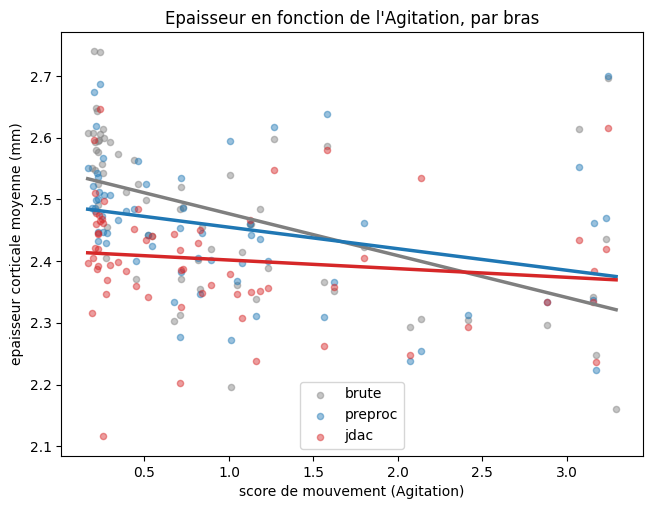

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
colors = {"brute": "tab:gray", "preproc": "tab:blue", "jdac": "tab:red"}
print("Pente de l'epaisseur en fonction de l'Agitation (mm par unite) :")
for arm in ["brute", "preproc", "jdac"]:
    sub = g[g["arm"] == arm]
    ax.scatter(sub["agitation"], sub["thickness"], s=20, alpha=0.45, color=colors[arm], label=arm)
    sl, inter, r, p, se = stats.linregress(sub["agitation"], sub["thickness"])
    xs = np.linspace(g["agitation"].min(), g["agitation"].max(), 50)
    ax.plot(xs, inter + sl * xs, color=colors[arm], lw=2.5)
    print(f"  {arm:8s}: {sl:+.4f}   (p={p:.2g})")
ax.set_xlabel("score de mouvement (Agitation)")
ax.set_ylabel("epaisseur corticale moyenne (mm)")
ax.set_title("Epaisseur en fonction de l'Agitation, par bras")
ax.legend()
plt.show()

L'épaisseur corticale moyenne diminue significativement avec l'agitation dans les images brutes.

Cette pente est atténuée après preprocessing rigide, puis encore davantage après JDAC. Cette lecture soutient l'idée que JDAC réduit l'association statistique entre mouvement et épaisseur, mais elle ne permet pas encore de distinguer une correction ciblée des artefacts d'un effet global de lissage ou de modification des intensités.

## 5. Stratification descriptive par niveau de mouvement mesuré

Les libellés still / nodding / shaking sont des consignes données au sujet, pas une mesure : nodding et shaking peuvent se recouvrir en score Agitation. Les acquisitions sont donc regroupées par niveau de mouvement réel, d'après le score Agitation (en mm) : faible (<= 0.3), léger (0.3 à 1.0), modéré (1.0 à 2.0), sévère (> 2.0). Ce découpage sert à visualiser la relation épaisseur-mouvement sans mélanger toute la plage 0.3-2.6 dans une seule catégorie. Il reste descriptif : les modèles continus des sections 4 et 8 gardent toute l'information du score Agitation. Vue inter-sujets : chaque niveau agrège des sujets différents.

In [7]:
# Niveaux de mouvement reel, decoupage descriptif plus fin
scans = g[["subject", "run", "agitation"]].drop_duplicates().copy()
scans["niveau"] = pd.cut(scans["agitation"], [0, 0.3, 1.0, 2.0, np.inf],
                         labels=["faible", "leger", "modere", "severe"],
                         include_lowest=True)
gb = g.merge(scans[["subject", "run", "niveau"]], on=["subject", "run"])

bornes = scans.groupby("niveau", observed=True)["agitation"].agg(n="count", min="min", max="max")
show(bornes, "Niveaux de mouvement (score Agitation : 0.3, 1.0, 2.0)",
     {"n": "{:.0f}", "min": "{:.2f}", "max": "{:.2f}"})

pivb = (gb.pivot_table(index="niveau", columns="arm", values="thickness", aggfunc="mean", observed=True)
          .reindex(["faible", "leger", "modere", "severe"])[["brute", "preproc", "jdac"]])
show(pivb, "Epaisseur moyenne (mm) par niveau de mouvement x bras", "{:.3f}")


,n,min,max
niveau,,,
faible,23,0.16,0.30
leger,18,0.34,0.89
modere,14,1.01,1.80
severe,11,2.07,3.29


arm,brute,preproc,jdac
niveau,,,
faible,2.583,2.516,2.431
leger,2.447,2.436,2.392
modere,2.426,2.434,2.381
severe,2.370,2.388,2.383


  L’épaisseur moyenne diminue avec le niveau de mouvement dans le bras brut. Cette diminution est moins marquée après
  preprocessing, puis encore plus faible après JDAC.

  Cette lecture reste descriptive : les niveaux simplifient un score continu et servent surtout à visualiser la tendance
  avant les tests.

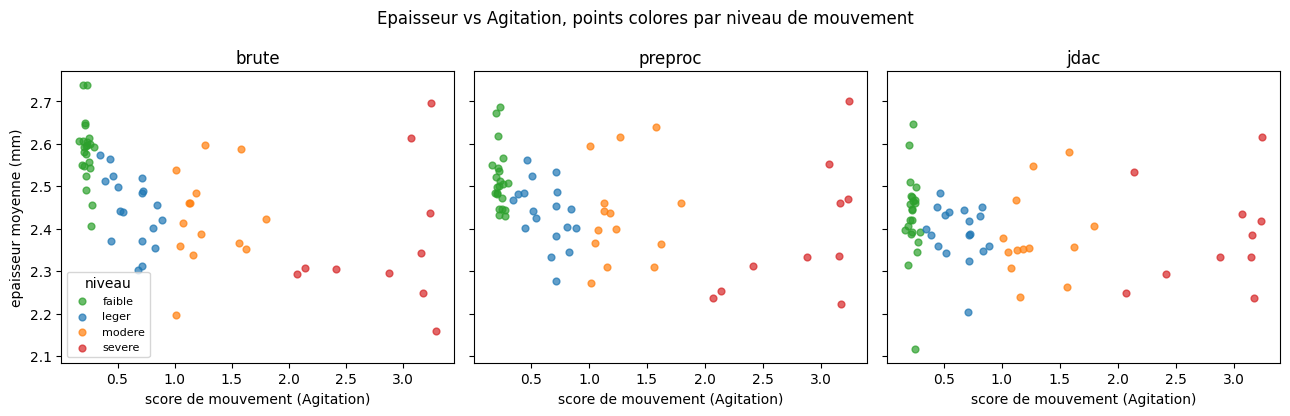

In [8]:
# Nuage : epaisseur vs Agitation, points colores par niveau de mouvement, un panneau par bras
col_niv = {"faible": "tab:green", "leger": "tab:blue", "modere": "tab:orange", "severe": "tab:red"}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, arm in zip(axes, ["brute", "preproc", "jdac"]):
    sub = gb[gb["arm"] == arm]
    for niv, s in sub.groupby("niveau", observed=True):
        ax.scatter(s["agitation"], s["thickness"], s=24, alpha=0.7, color=col_niv[niv], label=niv)
    ax.set_title(arm); ax.set_xlabel("score de mouvement (Agitation)")
axes[0].set_ylabel("epaisseur moyenne (mm)")
axes[0].legend(title="niveau", fontsize=8)
fig.suptitle("Epaisseur vs Agitation, points colores par niveau de mouvement")
plt.tight_layout(); plt.show()

## 6. Test catégoriel par niveau de mouvement (5bis)

Deux analyses utilisent les classes définies à la section 5 : (1) un modèle mixte `épaisseur ~ bras × niveau + (1 | sujet)` testant l'interaction bras × niveau, c'est-à-dire si l'écart entre bras dépend du niveau de mouvement ; (2) une comparaison par strate, l'écart jdac - brut et preproc - brut par niveau, avec test apparié. Les niveaux avec peu d'acquisitions sont peu puissants, leurs p-values sont indicatives.

Question posée ici : l'écart entre JDAC et le brut est-il le même en mouvement faible, léger, modéré et sévère ? Ce n'est pas le test continu principal de la pente épaisseur-agitation ; ce rôle revient au modèle mixte continu de la section 8.

In [9]:
# (1) Modele mixte avec interaction bras x niveau
gi = gb.copy()
gi["arm"] = pd.Categorical(gi["arm"], categories=["brute", "preproc", "jdac"])
fit_i = smf.mixedlm("thickness ~ C(arm, Treatment('brute')) * C(niveau, Treatment('faible'))",
                    gi, groups=gi["subject"]).fit(reml=True, method="powell", disp=False)
print("Interaction (jdac x niveau) : l'ecart jdac-brut depend-il du niveau de mouvement ?")
for k in fit_i.params.index:
    if ":" in k and "jdac" in k:
        niv = k.split("[T.")[-1].rstrip("]")
        print(f"  jdac x {niv:7s}: {fit_i.params[k]:+.4f}  (p={fit_i.pvalues[k]:.2g})")

# (2) Comparaison par strate : ecart au brut par niveau, test apparie
paire = (gb.pivot_table(index=["subject", "run", "niveau"], columns="arm",
                        values="thickness", observed=True)
           .dropna(subset=["brute"]).reset_index())
rows = []
for niv in ["faible", "leger", "modere", "severe"]:
    s = paire[paire["niveau"] == niv]
    rec = {"niveau": niv, "n": len(s)}
    for arm in ["preproc", "jdac"]:
        ss = s.dropna(subset=[arm])
        rec[f"{arm}-brut %"] = (100 * (ss[arm] - ss["brute"]) / ss["brute"]).mean()
        try:
            rec[f"p({arm})"] = stats.wilcoxon(ss[arm], ss["brute"]).pvalue
        except Exception:
            rec[f"p({arm})"] = float("nan")
    rows.append(rec)
strat = pd.DataFrame(rows).set_index("niveau")
show(strat, "Ecart au brut par niveau (%) et test apparie (Wilcoxon)",
     {"n": "{:.0f}", "preproc-brut %": "{:+.2f}", "p(preproc)": "{:.2g}",
      "jdac-brut %": "{:+.2f}", "p(jdac)": "{:.2g}"})

Interaction (jdac x niveau) : l'ecart jdac-brut depend-il du niveau de mouvement ?
  jdac x leger  : +0.0972  (p=0.013)
  jdac x modere : +0.1042  (p=0.014)
  jdac x severe : +0.1599  (p=0.00068)


,n,preproc-brut %,p(preproc),jdac-brut %,p(jdac)
niveau,,,,,
faible,23,-2.55,4.8e-06,-5.87,2.4e-07
leger,18,-0.40,0.44,-2.18,0.014
modere,14,+0.31,0.54,-2.58,0.0017
severe,10,-0.55,0.43,-0.28,0.36


## 7. Analyse intra-sujet des pentes (E2)

Pour chaque sujet et chaque bras, une régression de l'épaisseur sur l'Agitation résume la pente intra-sujet à partir des acquisitions disponibles, jusqu'à trois runs par sujet. Cette approche réduit l'influence des différences d'épaisseur de base entre sujets. Les pentes sont ensuite comparées entre bras avec un test apparié de Wilcoxon.

Limite : certains sujets peuvent contribuer une pente estimée sur deux acquisitions seulement si un run manque dans un bras.

  > Pour un même sujet, est-ce que l’épaisseur diminue moins avec le mouvement après JDAC que sur l’image brute ou
  > prétraitée ?


Pente mediane par bras :
arm
brute     -0.1601
jdac      -0.0569
preproc   -0.1034
Name: slope, dtype: float64


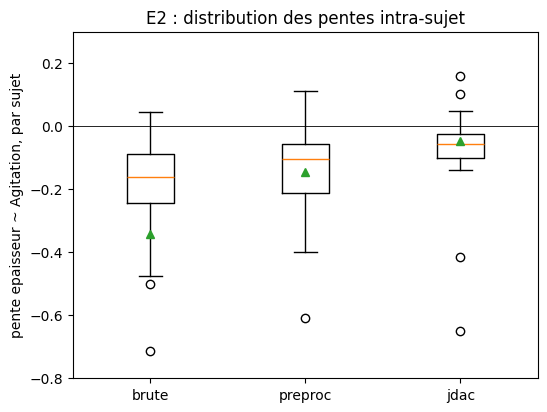


Tests apparies (Wilcoxon) sur les pentes par sujet :
  brute vs jdac (n=22): mediane brute=-0.1601, jdac=-0.0569, p=0.000593
  preproc vs jdac (n=22): mediane preproc=-0.1034, jdac=-0.0569, p=0.0738

Conclusion : pentes jdac plus plates que le brut (significatif) mais non distinctes de preproc ;
l'aplatissement de l'effet du mouvement vient surtout du pretraitement.


In [10]:
rows = []
for (subj, arm), sub in g.groupby(["subject", "arm"]):
    if len(sub) < 2 or sub["agitation"].std() == 0:
        continue
    sl = stats.linregress(sub["agitation"], sub["thickness"]).slope
    rows.append(dict(subject=subj, arm=arm, slope=sl))
pentes = pd.DataFrame(rows)

print("Pente mediane par bras :")
print(pentes.groupby("arm")["slope"].median().round(4))

fig, ax = plt.subplots(figsize=(6, 4.5))
data = [pentes[pentes["arm"] == a]["slope"] for a in ["brute", "preproc", "jdac"]]
ax.boxplot(data, labels=["brute", "preproc", "jdac"], showmeans=True)
ax.axhline(0, color="k", lw=0.6)
ax.set_ylim(-0.8, 0.3)  # axe borne : pentes sur 3 points, outliers hors champ
ax.set_ylabel("pente epaisseur ~ Agitation, par sujet")
ax.set_title("E2 : distribution des pentes intra-sujet")
plt.show()

print("\nTests apparies (Wilcoxon) sur les pentes par sujet :")
wide = pentes.pivot(index="subject", columns="arm", values="slope")
pv = {}
for a, b in [("brute", "jdac"), ("preproc", "jdac")]:
    pair = wide[[a, b]].dropna()
    pv[(a, b)] = stats.wilcoxon(pair[a], pair[b]).pvalue
    print(f"  {a} vs {b} (n={len(pair)}): mediane {a}={pair[a].median():+.4f}, "
          f"{b}={pair[b].median():+.4f}, p={pv[(a, b)]:.3g}")

if pv[("brute", "jdac")] < 0.05 and pv[("preproc", "jdac")] >= 0.05:
    print("\nConclusion : pentes jdac plus plates que le brut (significatif) mais non distinctes de preproc ;")
    print("l'aplatissement de l'effet du mouvement vient surtout du pretraitement.")
elif pv[("brute", "jdac")] < 0.05:
    print("\nConclusion : pentes jdac plus plates que le brut ET que preproc (aplatissement propre a JDAC).")
else:
    print("\nConclusion : pas d'aplatissement significatif des pentes par sujet pour jdac.")

## 8. Modèle continu principal (E3)

Modèle : `épaisseur ~ âge + sexe + Agitation × bras + (1 | sujet)`, référence = brute. Le coefficient `agitation` est la pente du brut ; le coefficient de bras est l'offset ; l'interaction `agitation × bras` est la variation de pente, coefficient décisif. L'effet aléatoire `(1 | sujet)` attribue à chaque sujet sa propre épaisseur de base.

C'est le test principal : il conserve le score Agitation continu, ajuste âge et sexe, et tient compte des mesures répétées par sujet. Le même modèle est ensuite réajusté par région, avec correction FDR.

In [11]:
g2 = g.copy()
g2["arm"] = pd.Categorical(g2["arm"], categories=["brute", "preproc", "jdac"])
fit = smf.mixedlm("thickness ~ age + sex_bin + agitation * C(arm, Treatment('brute'))",
                  g2, groups=g2["subject"]).fit(reml=True, method="powell", disp=False)

base = "C(arm, Treatment('brute'))"
def coef(name):
    return fit.params[name], fit.pvalues[name]

sl_b, p_slb  = coef("agitation")
off_p, p_offp = coef(f"{base}[T.preproc]")
off_j, p_offj = coef(f"{base}[T.jdac]")
chg_p, p_chgp = coef(f"agitation:{base}[T.preproc]")
chg_j, p_chgj = coef(f"agitation:{base}[T.jdac]")

print(f"pente brut              : {sl_b:+.4f}  (p={p_slb:.2g})")
print(f"offset preproc          : {off_p:+.4f}  (p={p_offp:.2g})")
print(f"offset jdac             : {off_j:+.4f}  (p={p_offj:.2g})")
print(f"variation de pente preproc : {chg_p:+.4f}  (p={p_chgp:.2g})")
print(f"variation de pente jdac    : {chg_j:+.4f}  (p={p_chgj:.2g})   <- coefficient decisif")
print(f"\nPentes resultantes : brut {sl_b:+.4f} | preproc {sl_b+chg_p:+.4f} | jdac {sl_b+chg_j:+.4f}")
if p_chgj < 0.05 and abs(sl_b + chg_j) < abs(sl_b):
    print("Conclusion : pente jdac significativement aplatie, effet du mouvement reduit.")
else:
    print("Conclusion : pente jdac non distincte du brut (offset / lissage).")

pente brut              : -0.0762  (p=4.5e-09)
offset preproc          : -0.0537  (p=0.024)
offset jdac             : -0.1275  (p=6.6e-08)
variation de pente preproc : +0.0301  (p=0.09)
variation de pente jdac    : +0.0505  (p=0.0043)   <- coefficient decisif

Pentes resultantes : brut -0.0762 | preproc -0.0462 | jdac -0.0257
Conclusion : pente jdac significativement aplatie, effet du mouvement reduit.


### 8b. Analyse régionale

Même modèle que ci-dessus, réajusté région par région. La p-value de l'interaction `Agitation × jdac` est corrigée FDR sur les régions. Cette analyse indique où l'aplatissement de la pente JDAC est spatialement le plus robuste.

In [12]:
# Modele mixte par region, avec correction FDR (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
rows = []
for (hemi, region), sub in df.groupby(["hemi", "region"]):
    if sub["arm"].nunique() < 3 or sub["agitation"].std() == 0:
        continue
    sub = sub.copy()
    sub["arm"] = pd.Categorical(sub["arm"], categories=["brute", "preproc", "jdac"])
    try:
        f = smf.mixedlm("thickness ~ age + sex_bin + agitation * C(arm, Treatment('brute'))",
                        sub, groups=sub["subject"]).fit(reml=True, method="powell", disp=False)
    except Exception:
        continue
    key = "agitation:C(arm, Treatment('brute'))[T.jdac]"
    if key in f.params.index:
        rows.append(dict(hemi=hemi, region=region, var_pente_jdac=f.params[key], p=f.pvalues[key]))
res = pd.DataFrame(rows)
res["p_fdr"] = multipletests(res["p"], method="fdr_bh")[1]
nsig = int((res["p_fdr"] < 0.05).sum())
print(f"Regions ou la pente jdac differe du brut (FDR<0.05) : {nsig} / {len(res)}")
print(f"Variation de pente jdac mediane sur les regions : {res['var_pente_jdac'].median():+.4f}")

# Table par region des effets FDR<0.05 (variation de pente jdac vs brut), triee
sig = res[res["p_fdr"] < 0.05].sort_values("var_pente_jdac", ascending=False).set_index(["hemi", "region"])
show(sig, f"Regions FDR<0.05 : variation de pente jdac vs brut ({nsig} regions)",
     {"var_pente_jdac": "{:+.4f}", "p": "{:.2g}", "p_fdr": "{:.2g}"})

Regions ou la pente jdac differe du brut (FDR<0.05) : 18 / 68
Variation de pente jdac mediane sur les regions : +0.0594


## 9. Lecture des résultats

La section 3 donne l'intuition par condition expérimentale. La section 4 vérifie la relation continue non ajustée entre Agitation et épaisseur. La section 5 rend le score Agitation lisible par classes descriptives, puis la section 6 teste si l'écart entre bras varie selon ces classes. La section 7 apporte une lecture intra-sujet appariée. La section 8 fournit le test formel principal : la variation de pente de jdac dans le modèle mixte continu, complétée par l'analyse régionale corrigée FDR.

La conclusion doit donc s'appuyer d'abord sur la section 8, puis utiliser les sections descriptives pour interpréter le mécanisme : correction ciblée du mouvement ou effet plus global de lissage / offset.